Bryan Huang (2025403110)
# Assignment 2: Time Series Forecasting with Classical and Deep Learning Methods




Background:
Time series forecasting is a fundamental task in time series analysis, involving the prediction of future
values based on historical data. In this assignment, I will apply both a classical forecasting method and
a deep learning-based method to perform multivariate time series forecasting on the ETT dataset.



For my classical forcasting method, I'll choose to use **Prophet**, and for my deep learning-based forcasting method, I'll choose to use the RNN-based **DeepAR** model.



Experimental Settings:

*   Input window size: 96
*   Prediction length: 96 and 192
*   Normalization: Standardize each feature (zero mean, unit variance) based on training data statistics.
Apply the same normalization to validation and test sets.
*   Dataset splitting: Split the data into training, validation, and test sets according to a 3:1:1 ratio in time
order.



# Set Up

Prep notebook for forcasting by installing necessary dependencys and downloading ETT dataset.


In [4]:
# Install Python 3.8 and the dependencies
# !apt-get update
# !apt-get install python3.8 python3.8-distutils
# !update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.8 1
# !update-alternatives --config python3
# !apt-get install python3-pip
# !python3 -m pip install --upgrade pip --user
# !pip install gdown

import os
import zipfile

dataset_dir = '/content/dataset'
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

# Download ETT dataset, unzip and store data paths to each CSV
!gdown 1bnrv7gpn27yO54WJI-vuXP5NclE5BlBx -O {dataset_dir}/ETT-small.zip
with zipfile.ZipFile(f"{dataset_dir}/ETT-small.zip", 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

Downloading...
From: https://drive.google.com/uc?id=1bnrv7gpn27yO54WJI-vuXP5NclE5BlBx
To: /content/dataset/ETT-small.zip
100% 3.97M/3.97M [00:00<00:00, 200MB/s]


# Prophet

Performing univariate forecasting using only the OT column for both training and prediction.




## 1. Setup and Dependencies

Import libraries needed for Prophet forcasting.

In [41]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## 2. Data Preprocessing
Create function to do the normalization and 3:1:1 datasplit for each of the ETT datasets.



**Implementation Note:**  
As Prophet is used as a baseline classical method without hyperparameter tuning:

- The validation set (20%) serves as the test set for final evaluation
- The original test set (20%) remains unused but preserved in splits

In [42]:
def load_and_preprocess_data(file_path, dataset_name):
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])

    # Standardize OT column using training data
    scaler = StandardScaler()
    train_size = int(len(df) * 0.6)
    val_size = int(len(df) * 0.2)

    # Split into train (60%), validation (20%), test (20%)
    train_df = df.iloc[:train_size]
    val_df = df.iloc[train_size:train_size+val_size]
    test_df = df.iloc[train_size+val_size:]

    # Fit scaler on training data
    scaler.fit(train_df[['OT']])

    # Normalize all splits
    train_prophet = train_df[['date', 'OT']].copy()
    train_prophet['y'] = scaler.transform(train_df[['OT']])
    val_prophet = val_df[['date', 'OT']].copy()
    val_prophet['y'] = scaler.transform(val_df[['OT']])

    # Rename for Prophet
    train_prophet = train_prophet.rename(columns={'date': 'ds'})
    val_prophet = val_prophet.rename(columns={'date': 'ds'})

    return train_prophet, val_prophet, scaler

## 3. Prophet Model Training and Forecasting
Forecast for each dataset on 96 and 192 step forcasting horizons. I generate plots to visualize each forecast to help with diagnosis.



INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpurouhnf6/kzgphvl0.json


Processing ETTh1...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpurouhnf6/5y759lzo.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=56003', 'data', 'file=/tmp/tmpurouhnf6/kzgphvl0.json', 'init=/tmp/tmpurouhnf6/5y759lzo.json', 'output', 'file=/tmp/tmpurouhnf6/prophet_modelhdawomny/prophet_model-20250428025044.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:50:44 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:50:47 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


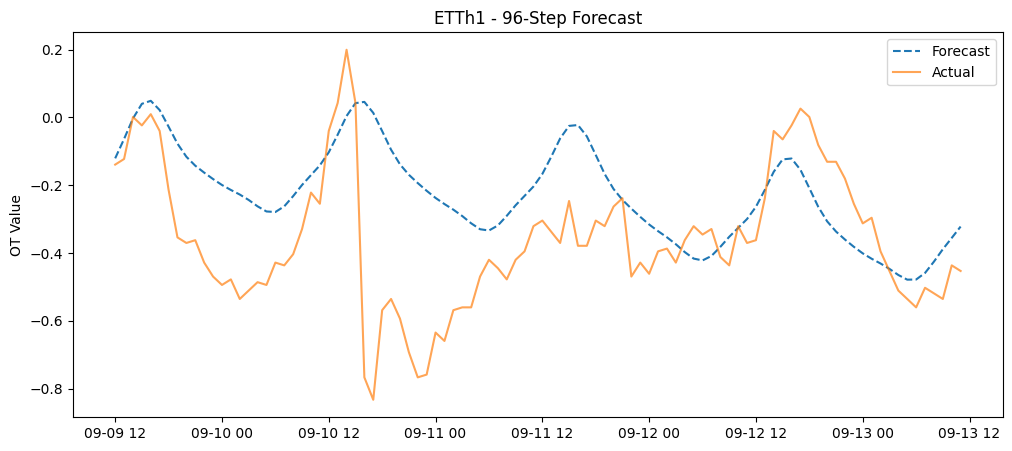

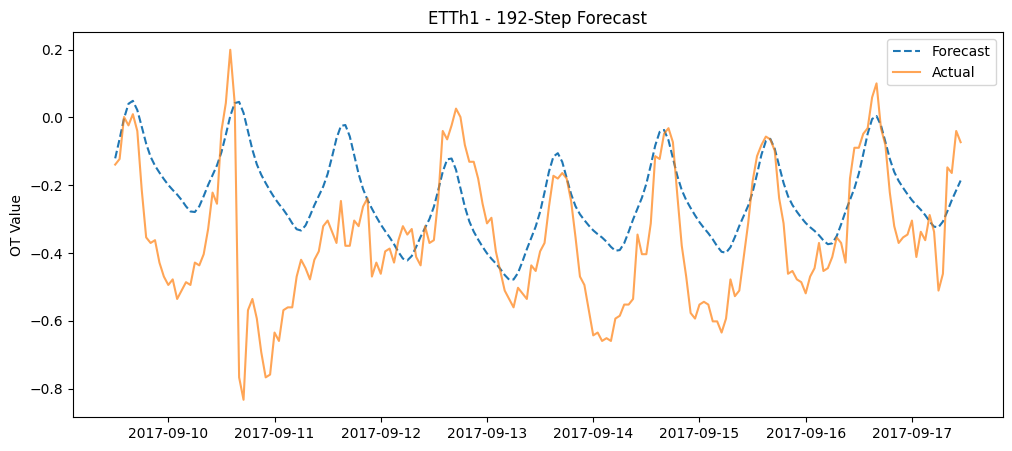

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpurouhnf6/yz5y9_ni.json


Processing ETTh2...


DEBUG:cmdstanpy:input tempfile: /tmp/tmpurouhnf6/wy5mo0b7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=41014', 'data', 'file=/tmp/tmpurouhnf6/yz5y9_ni.json', 'init=/tmp/tmpurouhnf6/wy5mo0b7.json', 'output', 'file=/tmp/tmpurouhnf6/prophet_modely44ycbhm/prophet_model-20250428025051.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:50:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:50:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


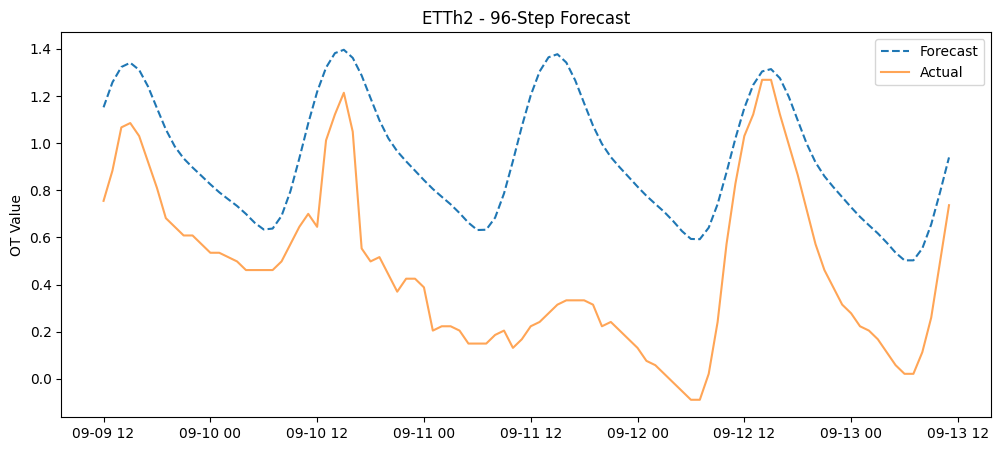

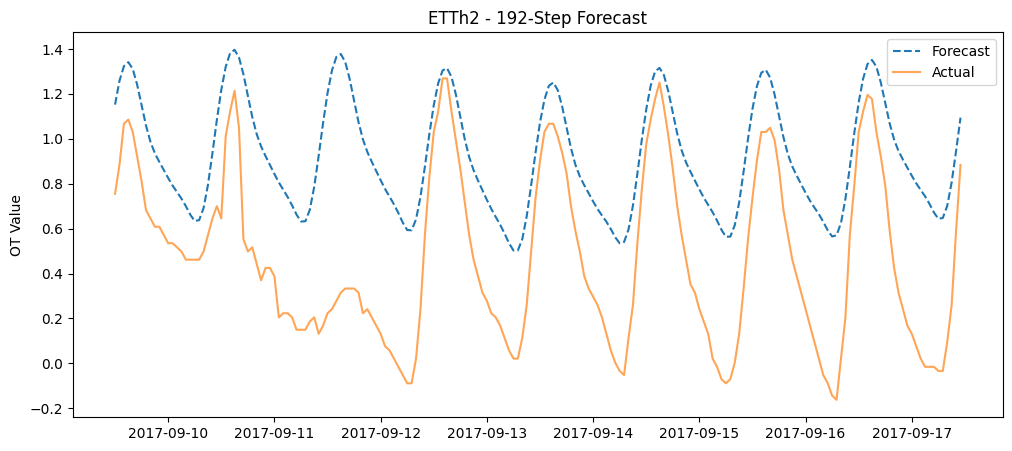

Processing ETTm1...


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpurouhnf6/lqbis473.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpurouhnf6/xx3ee7i7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=63767', 'data', 'file=/tmp/tmpurouhnf6/lqbis473.json', 'init=/tmp/tmpurouhnf6/xx3ee7i7.json', 'output', 'file=/tmp/tmpurouhnf6/prophet_modelez6wtlyv/prophet_model-20250428025058.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:50:58 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:51:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


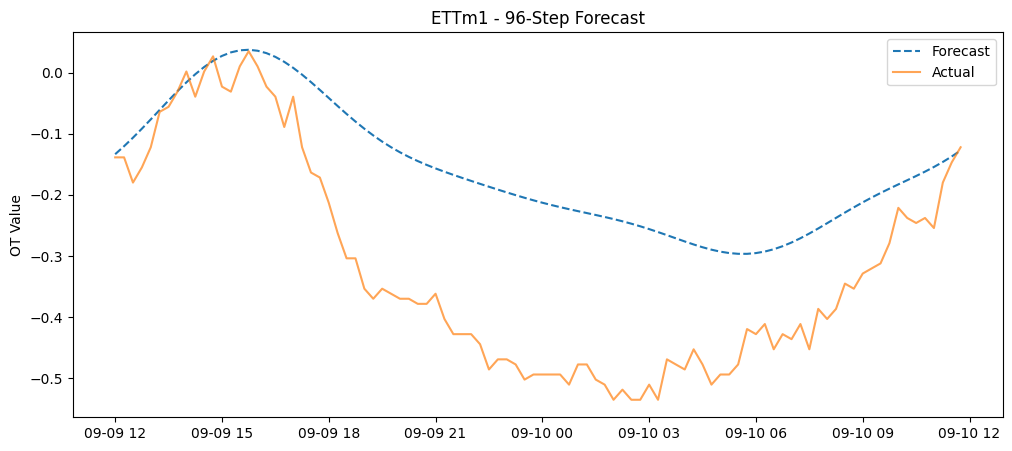

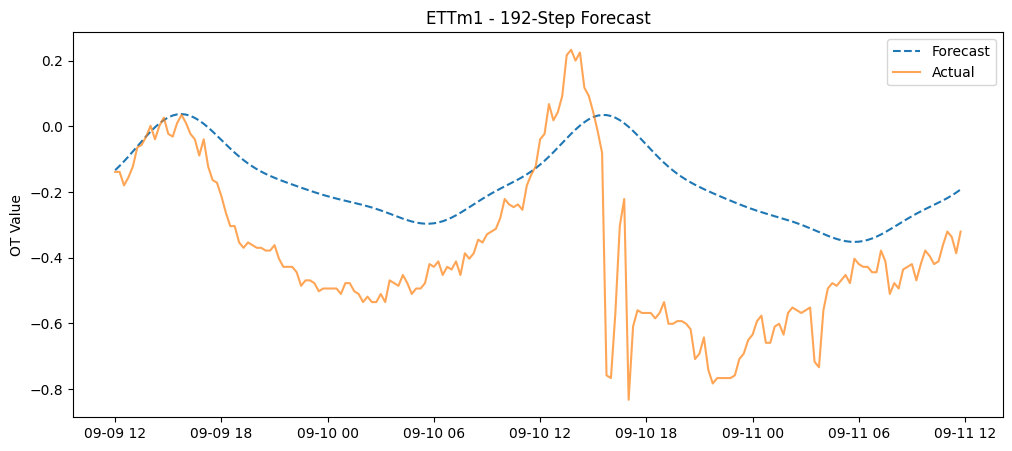

Processing ETTm2...


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpurouhnf6/p4mz3_3r.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpurouhnf6/prj0m45o.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95844', 'data', 'file=/tmp/tmpurouhnf6/p4mz3_3r.json', 'init=/tmp/tmpurouhnf6/prj0m45o.json', 'output', 'file=/tmp/tmpurouhnf6/prophet_modelp5xvwula/prophet_model-20250428025134.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:51:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:51:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


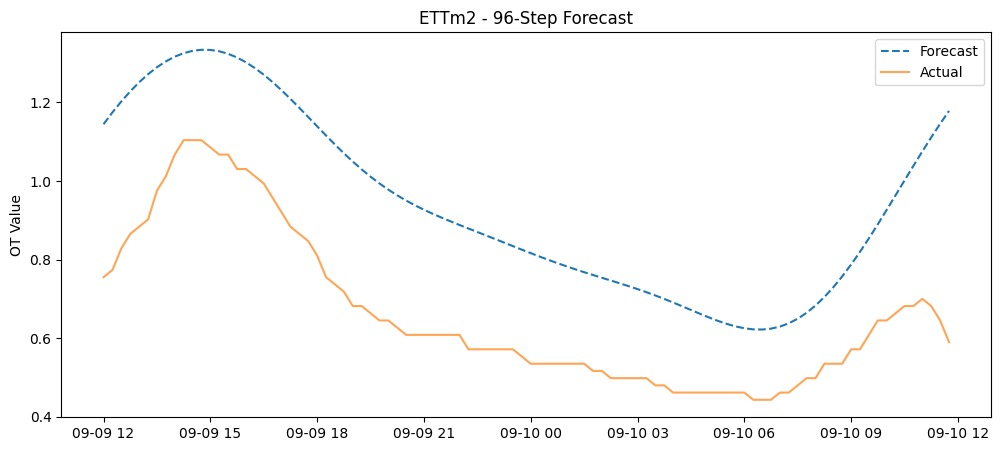

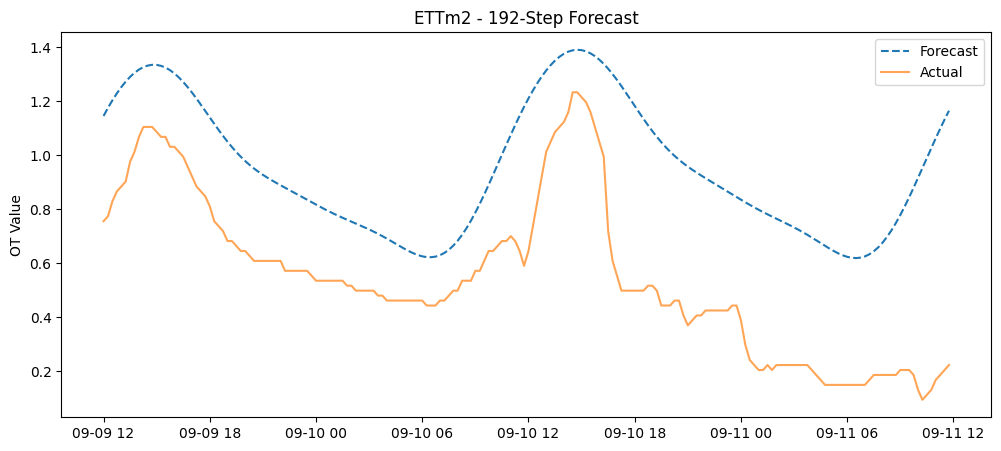

In [44]:
# Load datasets and prepare frequency mapping
data_paths = {
    'ETTh1': '/content/dataset/ETT-small/ETTh1.csv',
    'ETTh2': '/content/dataset/ETT-small/ETTh2.csv',
    'ETTm1': '/content/dataset/ETT-small/ETTm1.csv',
    'ETTm2': '/content/dataset/ETT-small/ETTm2.csv'
}

freq_map = {
    'ETTh1': 'h',
    'ETTh2': 'h',
    'ETTm1': '15min',
    'ETTm2': '15min'
}

results = {}

for name, path in data_paths.items():
    print(f"Processing {name}...")
    train_df, val_df, scaler = load_and_preprocess_data(path, name)
    freq = freq_map[name]

    model = Prophet()
    model.fit(train_df)

    # Forecast for 96 and 192 steps
    for pred_len in [96, 192]:
        future = model.make_future_dataframe(periods=pred_len, freq=freq)
        forecast = model.predict(future)

        # Extract predictions
        pred = forecast['yhat'].values[-pred_len:]
        actual = val_df['y'].values[:pred_len]

        # Plot in original scale for diagnosis
        plt.figure(figsize=(12, 5))
        plt.plot(val_df['ds'].iloc[:pred_len], pred, label='Forecast', linestyle='--')
        plt.plot(val_df['ds'].iloc[:pred_len], actual, label='Actual', alpha=0.7)
        plt.title(f"{name} - {pred_len}-Step Forecast")
        plt.ylabel("OT Value")
        plt.legend()
        plt.show()

        # Calculate and store metrics
        mse = mean_squared_error(actual, pred)
        mae = mean_absolute_error(actual, pred)
        results.setdefault(name, {})[pred_len] = {'MSE': mse, 'MAE': mae}


## 4. Evaluation and Results
Print the MSE and MAE for each dataset and prediction length.

In [45]:
# Display MSE and MAE results
for dataset, preds in results.items():
    print(f"\nResults for {dataset}:")
    for length, metrics in preds.items():
        print(f"  Prediction length {length}: MSE={metrics['MSE']:.4f}, MAE={metrics['MAE']:.4f}")


Results for ETTh1:
  Prediction length 96: MSE=0.0585, MAE=0.1817
  Prediction length 192: MSE=0.0412, MAE=0.1553

Results for ETTh2:
  Prediction length 96: MSE=0.2761, MAE=0.4683
  Prediction length 192: MSE=0.2506, MAE=0.4509

Results for ETTm1:
  Prediction length 96: MSE=0.0350, MAE=0.1607
  Prediction length 192: MSE=0.0798, MAE=0.2289

Results for ETTm2:
  Prediction length 96: MSE=0.0823, MAE=0.2770
  Prediction length 192: MSE=0.1926, MAE=0.4006


## 5. Discussion

Discussed MSE and MAE results:

| Dataset   | Prediction Length | MSE      | MAE      |
|-----------|-------------------|----------|----------|
| **ETTh1** | 96                | 0.0585   | 0.1817   |
|           | 192               | 0.0412   | 0.1553   |
| **ETTh2** | 96                | 0.2761   | 0.4683   |
|           | 192               | 0.2506   | 0.4509   |
| **ETTm1** | 96                | 0.0350   | 0.1607   |
|           | 192               | 0.0798   | 0.2289   |
| **ETTm2** | 96                | 0.0823   | 0.2770   |
|           | 192               | 0.1926   | 0.4006   |


Prophet's forcasting results were some-what suprising. For hourly datasets (ETTh1 and ETTh2), longer prediction horizons (192 steps) yield improved accuracy:

- ETTh1 achieves better performance at 192 steps (MSE=0.0412, MAE=0.1553) compared to 96 steps (MSE=0.0585, MAE=0.1817).

- ETTh2 also shows slight improvement at 192 steps (MSE=0.2506 vs. 0.2761 at 96 steps)

In contrast, 15-minute datasets (ETTm1 and ETTm2) exhibit degraded performance with longer forecasts:

- ETTm1 sees MSE nearly double from 0.0350 (96 steps) to 0.0798 (192 steps), likely due to noise amplification in high-frequency data.

- ETTm2’s MSE more than doubles (0.0823 to 0.1926)

This underscores Prophet’s strengths in capturing slower-evolving trends (hourly) but limitations in modeling rapid fluctuations (15-minute). For high-frequency data, deep learning models with sequence-aware architectures (e.g., Transformers) may better handle long-range dependencies.

# DeepAR

Performing multivariate forecasting on the OT column for both training and prediction.

## 1. Setup and Dependencies

In [10]:
!pip install "gluonts[torch]"

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from gluonts.dataset.common import ListDataset
from gluonts.dataset.field_names import FieldName
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.evaluation import Evaluator
from gluonts.evaluation.backtest import make_evaluation_predictions
import torch
import matplotlib.pyplot as plt

## 2. Data Preprocessing
Load the ETT datasets (ETTh1, ETTh2, ETTm1, ETTm2), standardize all features (zero mean, unit variance), and split the data into training, validation, and test sets in a 3:1:1 ratio. The input window size is 96, and prepared the data for multivariate forecasting using all features to predict the OT column.


Also must convert convert the preprocessed data into GluonTS `ListDataset` format.

In [22]:
def load_and_preprocess_data(file_path, input_window=96):
    # Load dataset
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

    # Standardize features
    scaler = StandardScaler()
    features = df.columns.tolist()
    df[features] = scaler.fit_transform(df[features])

    # Split data: 3:1:1 ratio
    total_len = len(df)
    train_len = int(total_len * 0.6)
    val_len = int(total_len * 0.2)
    test_len = total_len - train_len - val_len

    train_df = df.iloc[:train_len]
    val_df = df.iloc[train_len:train_len + val_len]
    test_df = df.iloc[train_len + val_len:]

    return train_df, val_df, test_df, features, scaler

def create_gluonts_dataset(df, features, target_col='OT', freq='h'):
    return ListDataset(
        [{
            FieldName.TARGET: df[target_col].values,
            FieldName.START: df.index[0],
            FieldName.FEAT_DYNAMIC_REAL: df[features].values.T
        }],
        freq=freq
    )

# 3. Training

Configure the DeepAR model with an input window of 96, prediction lengths of 96 and 192, and train it on each dataset. The model uses 2 layers, 40 hidden units, and a learning rate of 1e-3, trained for up to 25 epochs.

In [23]:
def train_deepar(train_ds, val_ds, freq, prediction_length):
    estimator = DeepAREstimator(
        freq=freq,
        context_length=96,
        prediction_length=prediction_length,
        num_layers=2,
        hidden_size=40,
        lr=1e-3,
        trainer_kwargs={'max_epochs': 25}
    )
    predictor = estimator.train(training_data=train_ds, validation_data=val_ds)
    return predictor

## 4. Evaluation
Calculate MSE and MAE metrics for evaluation.

In [24]:
def evaluate_model(predictor, test_ds, scaler, prediction_length, target_col='OT'):
    # Generate predictions
    forecast_it, ts_it = make_evaluation_predictions(
        dataset=test_ds,
        predictor=predictor,
        num_samples=100
    )
    forecasts = list(forecast_it)
    actuals = list(ts_it)

    # Extract mean predictions and actual values
    predictions = forecasts[0].mean
    actual_values = actuals[0].values[-prediction_length:]  # Access values directly from time series

    # Compute metrics
    mse = mean_squared_error(actual_values, predictions)
    mae = mean_absolute_error(actual_values, predictions)

    return mse, mae

# 5. Execution

Run above functions for each dataset.

In [25]:
data_paths = {
    'ETTh1': '/content/dataset/ETT-small/ETTh1.csv',
    'ETTh2': '/content/dataset/ETT-small/ETTh2.csv',
    'ETTm1': '/content/dataset/ETT-small/ETTm1.csv',
    'ETTm2': '/content/dataset/ETT-small/ETTm2.csv'
}

results = []
for dataset_name, file_path in data_paths.items():
    # Set frequency based on dataset
    freq = '15min' if 'm' in dataset_name else 'h'

    # Preprocess data
    train_df, val_df, test_df, features, scaler = load_and_preprocess_data(file_path)

    # Create GluonTS datasets
    train_ds = create_gluonts_dataset(train_df, features, freq=freq)
    val_ds = create_gluonts_dataset(val_df, features, freq=freq)
    test_ds = create_gluonts_dataset(test_df, features, freq=freq)

    for pred_length in [96, 192]:
        # Train model
        predictor = train_deepar(train_ds, val_ds, freq, pred_length)

        # Evaluate
        mse, mae = evaluate_model(predictor, test_ds, scaler, pred_length)
        results.append({
            'Dataset': dataset_name,
            'Prediction Length': pred_length,
            'MSE': mse,
            'MAE': mae
        })

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type        | Params | Mode  | In sizes                                                      | Out sizes   
-----------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 27.6 K | train | [[1, 1], [1, 1], [1, 816, 5], [1, 816], [1, 816], [1, 96, 5]] | [1, 100, 96]
---------------------------------------------------------------------------------------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 0, global step 50: 'val_loss' reached 1.02316 (best 1.02316), saving model to '/content/lightning_logs/version_8/checkpoints/epoch=0-step=50.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 50: 'val_loss' reached 1.02316 (best 1.02316), saving model to '/content/lightning_logs/version_8/checkpoints/epoch=0-step=50.ckpt' as top 1


...

INFO: Epoch 22, global step 1150: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 22, global step 1150: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 23, global step 1200: 'val_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 23, global step 1200: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 24, global step 1250: 'val_loss' reached -1.96101 (best -1.96101), saving model to '/content/lightning_logs/version_15/checkpoints/epoch=24-step=1250.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 24, global step 1250: 'val_loss' reached -1.96101 (best -1.96101), saving model to '/content/lightning_logs/version_15/checkpoints/epoch=24-step=1250.ckpt' as top 1
INFO: `Trainer.fit` stopped: `max_epochs=25` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.


# 5. Results

In [31]:
results_df = pd.DataFrame(results)
for _, row in results_df.iterrows():
    print(f"Results for {row['Dataset']} at prediction length {row['Prediction Length']} : MSE={row['MSE']:.4f}, MAE={row['MAE']:.4f}")

Results for ETTh1 at prediction length 96 : MSE=0.0461, MAE=0.1667
Results for ETTh1 at prediction length 192 : MSE=0.1131, MAE=0.2784
Results for ETTh2 at prediction length 96 : MSE=0.1266, MAE=0.3066
Results for ETTh2 at prediction length 192 : MSE=0.6979, MAE=0.6538
Results for ETTm1 at prediction length 96 : MSE=0.0046, MAE=0.0446
Results for ETTm1 at prediction length 192 : MSE=0.3007, MAE=0.4994
Results for ETTm2 at prediction length 96 : MSE=0.1173, MAE=0.2741
Results for ETTm2 at prediction length 192 : MSE=0.1096, MAE=0.2868


# Discussion

Discussed MSE and MAE results:

| Dataset   | Prediction Length | MSE      | MAE      |
|-----------|-------------------|----------|----------|
| **ETTh1** | 96                | 0.0461   | 0.1667   |
|           | 192               | 0.1131   | 0.2784   |
| **ETTh2** | 96                | 0.1266   | 0.3066   |
|           | 192               | 0.6979   | 0.6538   |
| **ETTm1** | 96                | 0.0046   | 0.0446   |
|           | 192               | 0.3007   | 0.4994   |
| **ETTm2** | 96                | 0.1173   | 0.2741   |
|           | 192               | 0.1096   | 0.2868   |


DeepAR shows a nuanced performance profile across the ETT datasets, reflecting its strengths and weaknesses as an auto-regressive, RNN-based forecasting model. For high-frequency 15-minute data (ETTm1), the model achieves a strong performance at short horizons (MSE=0.0046, MAE=0.0446 for 96 steps), showcasing its ability to capture rapid temporal dependencies in finely sampled sequences. However, its performance degrades sharply at longer horizons (MSE=0.3007, MAE=0.4994 for 192 steps), likely due to error propagation and the challenge of maintaining coherence in complex, long-range patterns.

The model’s behavior on ETTm2 reveals a strange inconsistency: while MSE slightly improves at 192 steps (0.1096 vs. 0.1173 at 96 steps), MAE worsens (0.2868 vs. 0.2741), suggesting that predictions become less variable but systematically biased over time. For hourly datasets (ETTh1 and ETTh2), DeepAR struggles to retain accuracy, particularly at longer preditction horizons (e.g., ETTh2’s MSE=0.6979 at 192 steps). This highlights its sensitivity to dataset-specific temporal dynamics, where slower-evolving trends or weaker short-term dependencies may limit its ability to leverage sequential context effectively. Overall, DeepAR excels in high-frequency, short-term forecasting but faces challenges in balancing bias and variance for complex, long-horizon tasks.
